# Visualisation

# Employee Attrition Data Visualisation

## Objectives

- Create clear and professional visualisations to communicate employee attrition patterns.
- Visualise the main findings from the EDA and hypothesis testing.
- Explore employee and workplace factors associated with attrition.
- Visualise key machine learning results including model performance and feature importance.
- Support the project Business Requirements with data-driven visual storytelling.

## Inputs

- `data/clean/hr_attrition_clean.csv`
- `data/clean/feature_importance.csv`
- `data/clean/model_comparison.csv`
- Findings from the EDA and Machine Learning notebooks

## Outputs

- Static visualisations created using Matplotlib and Seaborn.
- Interactive visualisations created using Plotly.
- Visual insights supporting the Business Requirements and hypotheses.
- Key charts that will inform the final Power BI dashboard.

## Additional Comments

The visualisations in this notebook are designed to complement the EDA and machine learning analysis.  
The focus is on communicating the most important findings clearly rather than reproducing every analysis step.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\CodeInstitute\\employee-attrition-hackathon\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\CodeInstitute\\employee-attrition-hackathon'

# Import Libraries and Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


In [5]:
df = pd.read_csv("data/clean/hr_attrition_clean.csv")
feature_importance = pd.read_csv("data/clean/feature_importance.csv")
model_comparison = pd.read_csv("data/clean/model_comparison.csv")

print(f"Employee dataset shape: {df.shape}")
display(df.head())

Employee dataset shape: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


---

##  Overall Employee Attrition

This section provides an overview of employee attrition in the dataset by comparing the number and percentage of employees who stayed with those who left the company.

In [6]:
attrition_counts = df["Attrition"].value_counts()
attrition_percent = df["Attrition"].value_counts(normalize=True) * 100

print(attrition_counts)
print()
print(attrition_percent.round(1))


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


In [9]:
fig = px.pie(
    values=attrition_counts.values,
    names=attrition_counts.index,
    hole=0.55,
    title="Overall Employee Attrition"
)

fig.update_traces(textinfo="label+percent+value", pull=[0, 0.08])
fig.show()


### Attrition Rate by Department

This visual compares the percentage of employees who left across the three departments.


In [10]:
department_attrition = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name="AttritionRate")
)

department_attrition


,Department,AttritionRate
0,Sales,20.627803
1,Human Resources,19.047619
2,Research & Development,13.839750


In [11]:
fig = px.bar(
    department_attrition,
    x="Department",
    y="AttritionRate",
    color="Department",
    text_auto=".1f",
    title="Attrition Rate by Department"
)

fig.show()


### Attrition Rate by Job Role

This visual compares employee attrition rates across different job roles.


In [12]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values()
)

jobrole_attrition


JobRole
Research Director             2.500000
Manager                       4.901961
Healthcare Representative     6.870229
Manufacturing Director        6.896552
Research Scientist           16.095890
Sales Executive              17.484663
Human Resources              23.076923
Laboratory Technician        23.938224
Sales Representative         39.759036
Name: Attrition, dtype: float64

In [13]:
fig = px.bar(
    jobrole_attrition,
    orientation="h",
    title="Attrition Rate by Job Role"
)

fig.show()


---

## Overtime and Employee Attrition

This section examines whether employees who work overtime have a higher attrition rate.


In [14]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

overtime_attrition


OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

In [15]:
fig = px.bar(
    overtime_attrition,
    text_auto=".1f",
    title="Attrition Rate by Overtime"
)

fig.show()


---

## Monthly Income and Employee Attrition

This section explores the distribution of monthly income and its relationship with employee attrition.


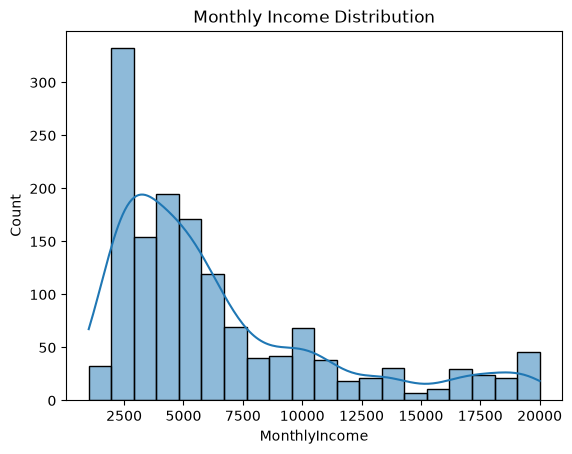

In [16]:
sns.histplot(df["MonthlyIncome"], kde=True)
plt.title("Monthly Income Distribution")
plt.show()


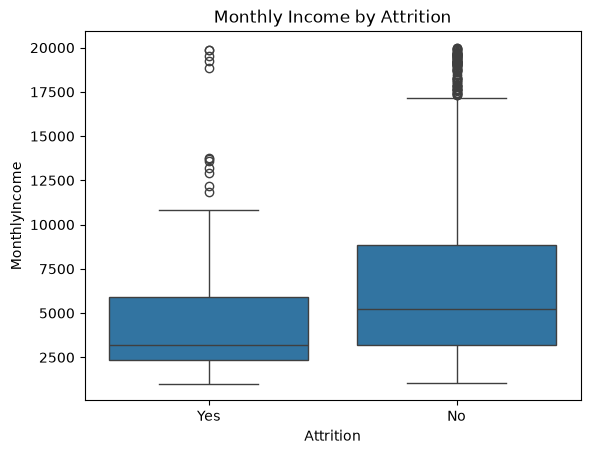

In [17]:
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income by Attrition")
plt.show()


---

## Job Satisfaction and Employee Attrition

This section explores how employee attrition varies across different levels of job satisfaction.


In [18]:
job_satisfaction = (
    df.groupby("JobSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

job_satisfaction


JobSatisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: Attrition, dtype: float64

In [19]:
fig = px.bar(
    job_satisfaction,
    text_auto=".1f",
    title="Attrition Rate by Job Satisfaction"
)

fig.update_traces(marker_color="crimson")
fig.show()


---

## Work Conditions and Employee Attrition

This section examines how work-life balance and environment satisfaction are associated with employee attrition.


In [20]:
worklife = (
    df.groupby("WorkLifeBalance")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

worklife


WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

In [21]:
fig = px.bar(
    worklife,
    text_auto=".1f",
    title="Attrition Rate by Work-Life Balance"
)

fig.show()


In [22]:
environment = (
    df.groupby("EnvironmentSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

environment


EnvironmentSatisfaction
1    25.352113
2    14.982578
3    13.686534
4    13.452915
Name: Attrition, dtype: float64

In [23]:
fig = px.bar(
    environment,
    text_auto=".1f",
    title="Attrition Rate by Environment Satisfaction"
)

fig.show()


---

## Attrition Drivers

This section explores the relationships between key numerical variables and highlights the most important drivers of employee attrition.


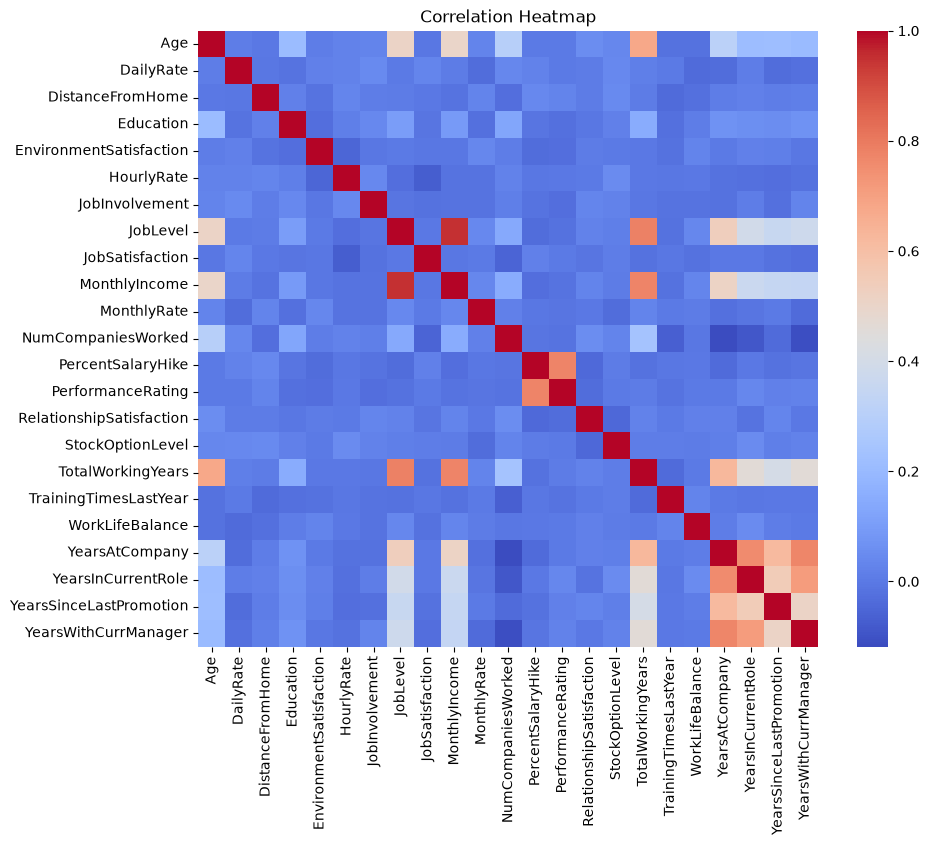

In [24]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [25]:
feature_importance.head()

,Unnamed: 0,0
0,num__MonthlyIncome,0.076761
1,num__Age,0.061698
2,num__TotalWorkingYears,0.056192
3,num__DailyRate,0.053835
4,num__HourlyRate,0.045703


In [29]:
fig = px.bar(
    feature_importance.head(10),
    x="0",
    y="Unnamed: 0",
    color="Unnamed: 0",
    orientation="h",
    title="Top 10 Important Features"
)

fig.show()

---

## Machine Learning Model Comparison

This section compares the performance of the machine learning models using Accuracy and Recall.


In [30]:
model_comparison

,Model,Accuracy,Recall_Yes
0,Majority-class baseline,0.8384,0.00
1,Logistic Regression,0.8605,0.34
2,Random Forest,0.8503,0.15


In [32]:
fig = px.bar(
    model_comparison,
    x="Model",
    y=["Accuracy", "Recall_Yes"],
    barmode="group",
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Model Performance Comparison"
)

fig.show()



---

## Interactive Attrition Analysis

This interactive visual explores employee attrition across departments and job roles.


In [33]:
fig = px.sunburst(
    df,
    path=["Department", "JobRole", "Attrition"],
    title="Attrition by Department and Job Role",
    color="Attrition"
)

fig.show()


---

## Key Insights

The analysis highlights the main factors associated with employee attrition and summarises the most important findings from the dataset.


In [34]:
key_insights = pd.DataFrame({
    "Factor": ["Overall Attrition", "Overtime", "Sales", "Sales Representative"],
    "Rate": [16.1, 30.5, 20.6, 39.8]
})

fig = px.bar(
    key_insights,
    x="Factor",
    y="Rate",
    color="Factor",
    text_auto=".1f",
    title="Key Attrition Insights"
)

fig.show()
